<a href="https://colab.research.google.com/github/VineelaYenigandla/test/blob/main/viz_day1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import numpy as np

data = {
    'order_id': [1,2,3,4,5,6,7,8,9,10],
    'customer': ['Ravi','Priya','Ravi','Ankit','Priya','Neha','Ankit','Ravi','Neha','Priya'],
    'city': ['Hyderabad','Mumbai','Hyderabad','Delhi','Mumbai','Hyderabad','Delhi','Mumbai','Hyderabad','Delhi'],
    'product': ['Laptop','Phone','Tablet','Laptop','Tablet','Phone','Phone','Laptop','Tablet','Phone'],
    'amount': [45000, 12000, 8000, 52000, 9000, 11000, 13000, 47000, 7500, 14000],
    'quantity': [1,2,1,1,3,2,1,1,2,1],
    'status': ['delivered','delivered','cancelled','delivered','returned','delivered','delivered','cancelled','delivered','delivered'],
    'discount_pct' : [5, 10, 0, 8, 15, 5, 3, 0, 12, 7],
    'delivery_days':[2, 5, 0, 3, 0, 4, 2, 0, 3, 6]
}

df = pd.DataFrame(data)

print(df)

   order_id customer       city product  amount  quantity     status  \
0         1     Ravi  Hyderabad  Laptop   45000         1  delivered   
1         2    Priya     Mumbai   Phone   12000         2  delivered   
2         3     Ravi  Hyderabad  Tablet    8000         1  cancelled   
3         4    Ankit      Delhi  Laptop   52000         1  delivered   
4         5    Priya     Mumbai  Tablet    9000         3   returned   
5         6     Neha  Hyderabad   Phone   11000         2  delivered   
6         7    Ankit      Delhi   Phone   13000         1  delivered   
7         8     Ravi     Mumbai  Laptop   47000         1  cancelled   
8         9     Neha  Hyderabad  Tablet    7500         2  delivered   
9        10    Priya      Delhi   Phone   14000         1  delivered   

   discount_pct  delivery_days  
0             5              2  
1            10              5  
2             0              0  
3             8              3  
4            15              0  
5        

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8')
sns.set_theme(style='whitegrid',palette='muted')



Viz Task 1 — Bar chart (Matplotlib)
Plot total amount spent per city as a bar chart. Use the OO interface — fig, ax.
Requirements:

Title: "Total Revenue by City"
X label: "City"
Y label: "Revenue (₹)"
Use ax.bar(), not plt.bar()
```
# This is formatted as code
```



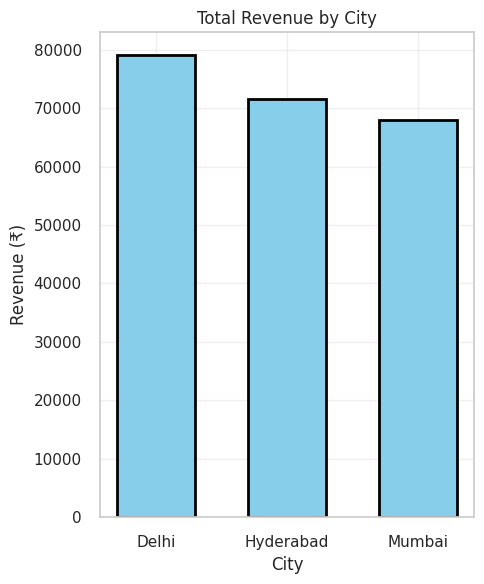

In [20]:
city_revenue= df.groupby('city')['amount'].sum()
fig,ax=plt.subplots(figsize=(5,6))
ax.bar(city_revenue.index,
       city_revenue.values,
       color='skyblue',
       linewidth=2,
       edgecolor='black',
       width=0.6)
ax.set_title ("Total Revenue by City")
ax.set_xlabel("City")
ax.set_ylabel("Revenue (₹)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Show the count of orders by status using Seaborn. Add a title and axis labels.


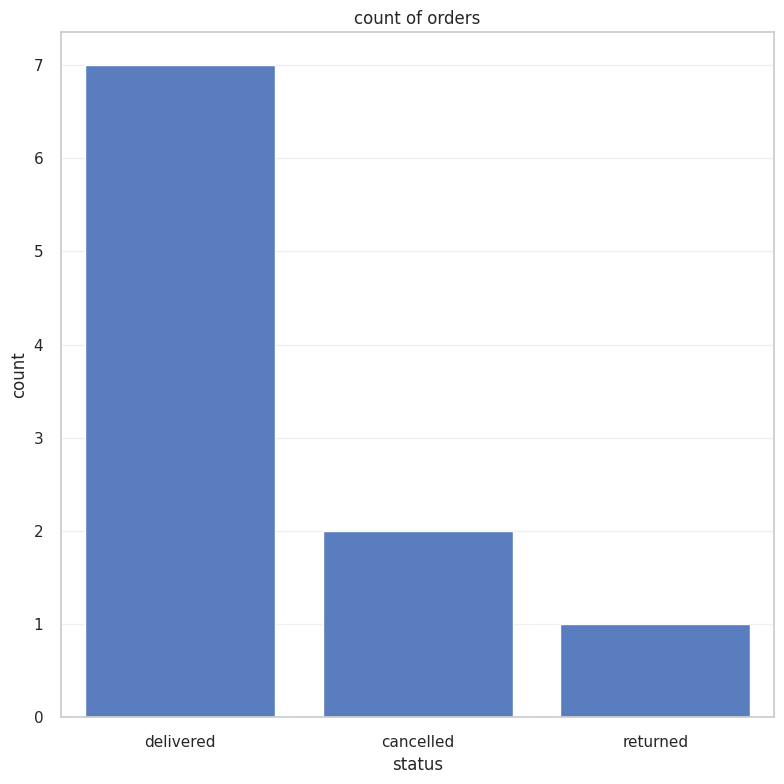

In [21]:

fig,ax=plt.subplots(figsize=(8,8))
sns.countplot(data=df,
              x='status',
              ax=ax)
ax.set_title("count of orders")
ax.set_xlabel("status")
ax.set_ylabel("count")
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()



Viz Task 3 — Seaborn barplot with hue
Show average order amount per city, coloured by product category using hue=.

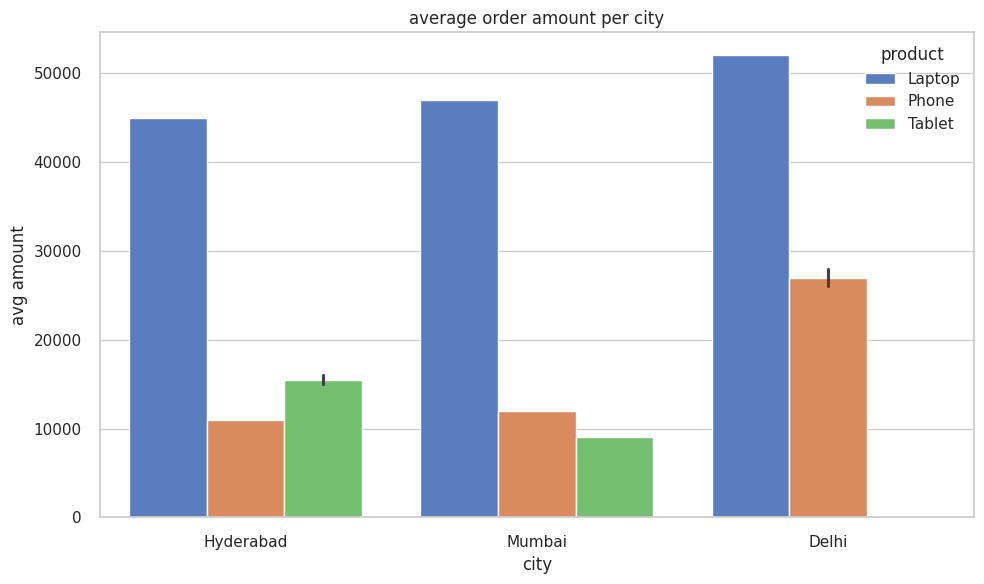

In [22]:
fig,ax=plt.subplots(figsize=(10,6))

sns.barplot(data=df, x='city', y='amount', hue='product',
            estimator=sum, ax=ax)
ax.set_title("average order amount per city")
ax.set_xlabel("city")
ax.set_ylabel("avg amount")

plt.tight_layout()
plt.show()


Viz Task 4 — 2-chart subplot dashboard
Put Task 1 and Task 2 side by side in one figure using plt.subplots(1,2).
Requirements:

figsize=(14, 5)
plt.tight_layout() before show
Both charts have titles
Save it: plt.savefig('day1_dashboard.png', dpi=150, bbox_inches='tight')




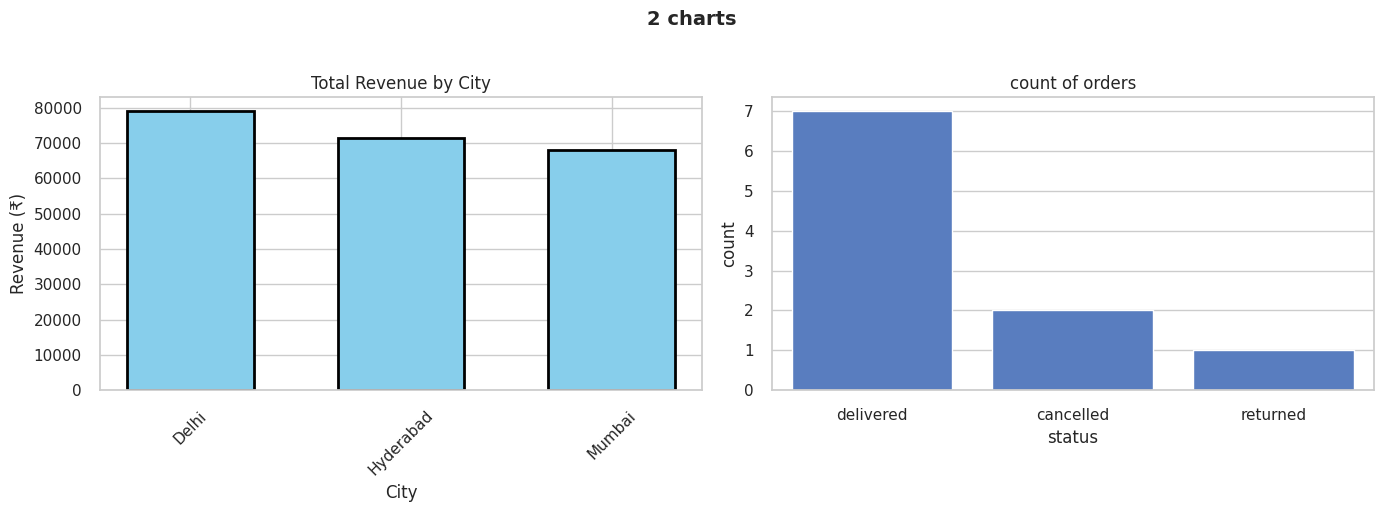

In [23]:
fig,ax=plt.subplots(1,2,figsize=(14,5))
city_revenue= df.groupby('city')['amount'].sum()
ax[0].bar(city_revenue.index,
       city_revenue.values,
       color='skyblue',
       linewidth=2,
       edgecolor='black',
       width=0.6)
ax[0].set_title ("Total Revenue by City")
ax[0].set_xlabel("City")
ax[0].set_ylabel("Revenue (₹)")
ax[0].tick_params(axis='x', rotation=45)
sns.countplot(data=df,
              x='status',
              ax=ax[1])
ax[1].set_title("count of orders")
ax[1].set_xlabel("status")
ax[1].set_ylabel("count")

fig.suptitle('2 charts',fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart1.png',dpi=300,bbox_inches='tight')
plt.show()


Show total revenue per customer as a horizontal bar. Customers sorted highest to lowest.


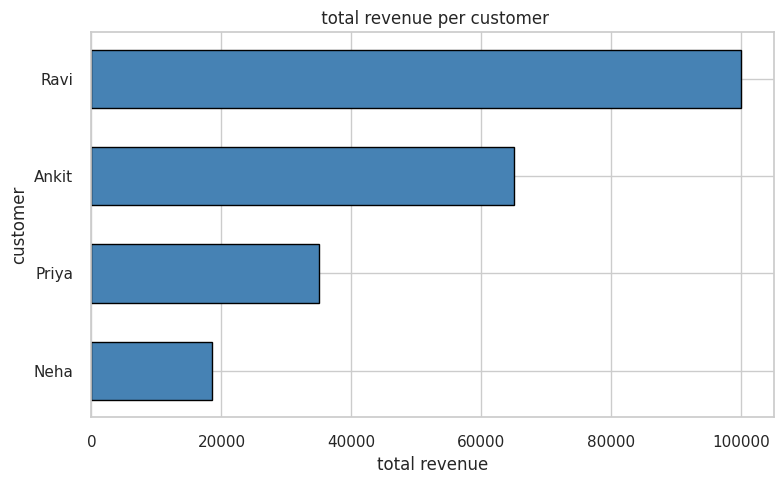

In [24]:
fig, ax = plt.subplots(figsize=(8,5))
customer_rev = df.groupby('customer')['amount'].sum().sort_values()
# Use ax.barh() — horizontal bar
ax.barh(customer_rev.index,customer_rev.values,
        color='steelblue',
        edgecolor='black',
        height=0.6
        )

ax.set_title(" total revenue per customer")
ax.set_xlabel("total revenue")
ax.set_ylabel("customer")
plt.tight_layout()
plt.show()

Plot delivery_days vs amount to see if higher value orders take longer to deliver.


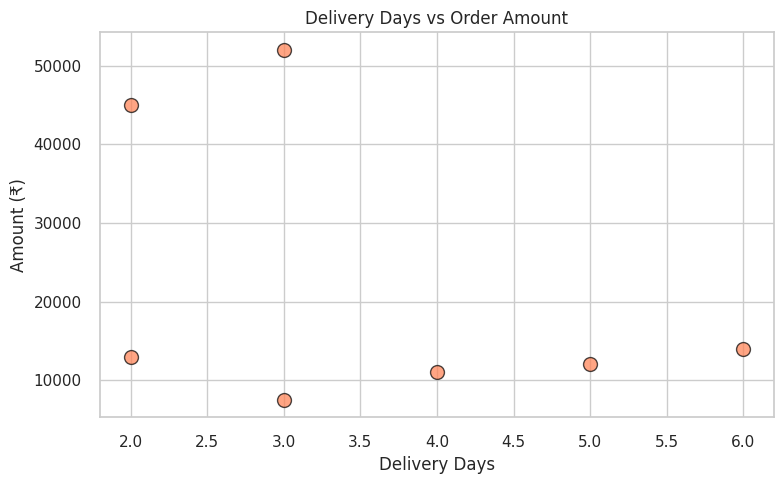

In [25]:
fig, ax = plt.subplots(figsize=(8,5))

# s = dot size, alpha = transparency
# Filter out cancelled/returned first (delivery_days=0 for those)
delivered = df[df['status']=='delivered']
# plot delivered['delivery_days'] vs delivered['amount']
ax.scatter(x=delivered['delivery_days'], y=delivered['amount'], color='coral', s=100, edgecolors='black', alpha=0.7)
ax.set_title('Delivery Days vs Order Amount')
ax.set_xlabel('Delivery Days')
ax.set_ylabel('Amount (₹)')
plt.tight_layout()
plt.show()


Show the distribution of amount. Use both Matplotlib histogram AND Seaborn histplot with KDE. Side by side in one figure.


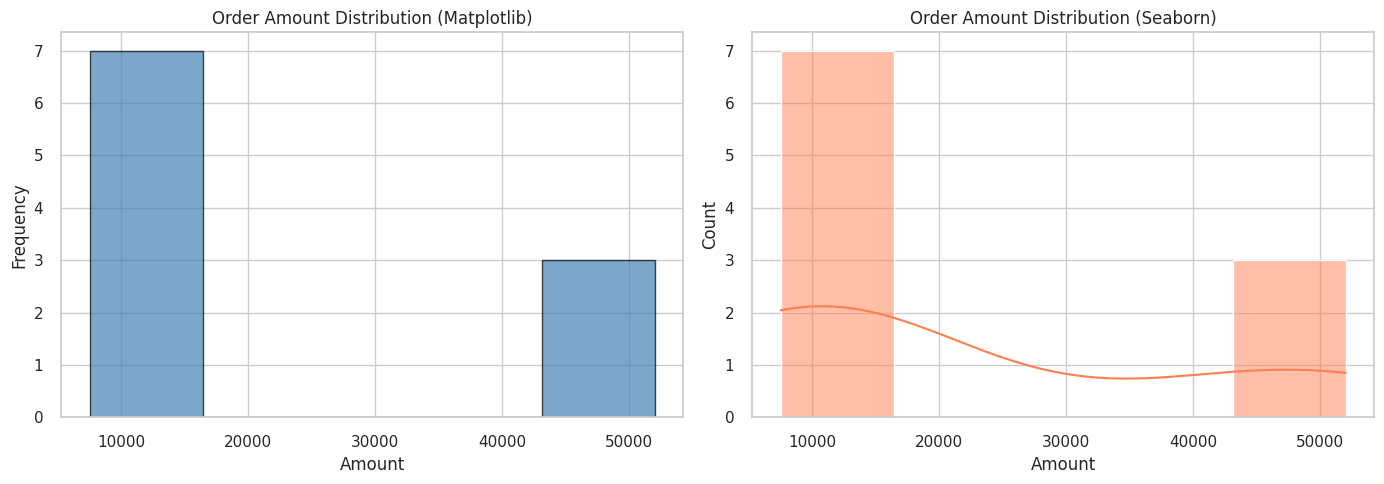

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Left: Matplotlib histogram
axes[0].hist(df['amount'], bins=5, color='steelblue',
             edgecolor='black', alpha=0.7)
axes[0].set_title('Order Amount Distribution (Matplotlib)')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')

# Right: Seaborn histplot with KDE
sns.histplot(data=df, x='amount', kde=True,
             color='coral', ax=axes[1])
axes[1].set_title('Order Amount Distribution (Seaborn)')
axes[1].set_xlabel('Amount')

plt.tight_layout()
plt.show()

Task 8 — Axis control + tick rotation
Plot monthly-style data with long labels. Practice xlim, ylim, tick rotation.

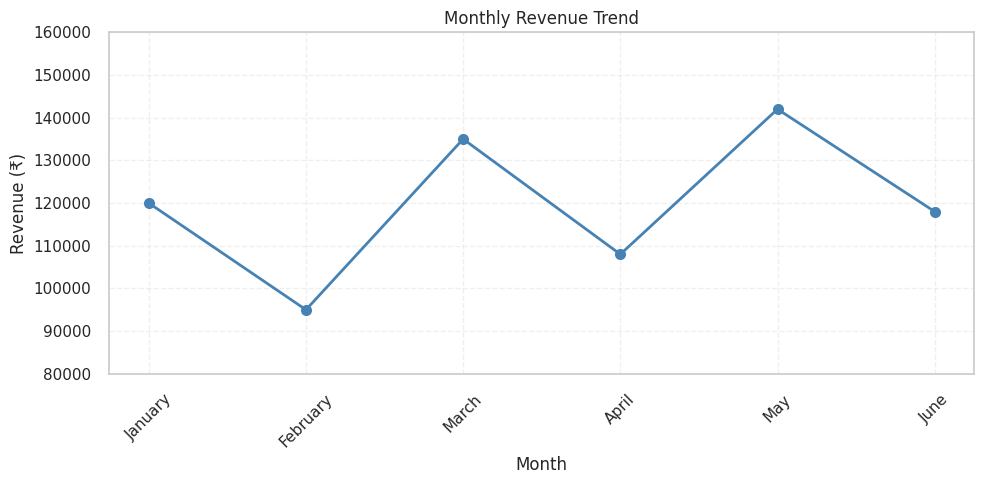

In [15]:
months = ['January','February','March','April','May','June']
revenue = [120000, 95000, 135000, 108000, 142000, 118000]

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(months, revenue, marker='o', color='steelblue',
        linewidth=2, markersize=8)
ax.set_title('Monthly Revenue Trend')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (₹)')

# Add these one by one and see what changes:

ax.set_ylim(80000, 160000)
ax.tick_params(axis='x', rotation=45)

ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

Task 9 — Annotations (highlight a key insight)
Take your monthly revenue line chart from Task 8. Annotate the highest month with an arrow and label.

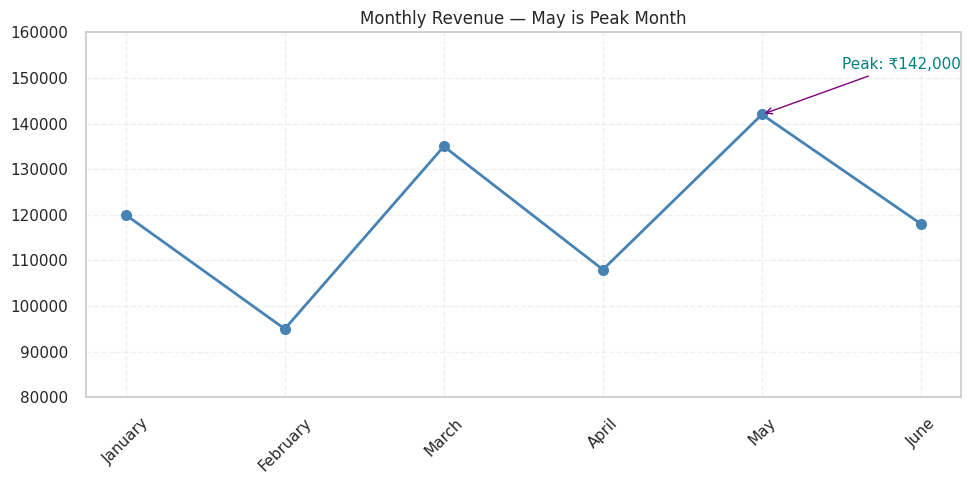

In [16]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(months, revenue, marker='o', color='steelblue',
        linewidth=2, markersize=8)

# Find the max
max_idx = revenue.index(max(revenue))
max_month = months[max_idx]
max_val = max(revenue)

# Annotate it
ax.annotate(
    f'Peak: ₹{max_val:,}',          # text
    xy=(max_idx, max_val),           # point to annotate
    xytext=(max_idx+0.5, max_val+10000),  # where text appears
    arrowprops=dict(arrowstyle='->', color='purple'),
    fontsize=11,
    color='teal'
)

ax.set_title('Monthly Revenue — May is Peak Month')
ax.set_ylim(80000, 160000)
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


Combine Tasks 5, 6, 7 (Seaborn version), and 8 into one 2×2 dashboard. This is your Day 1 complete visualisation output.

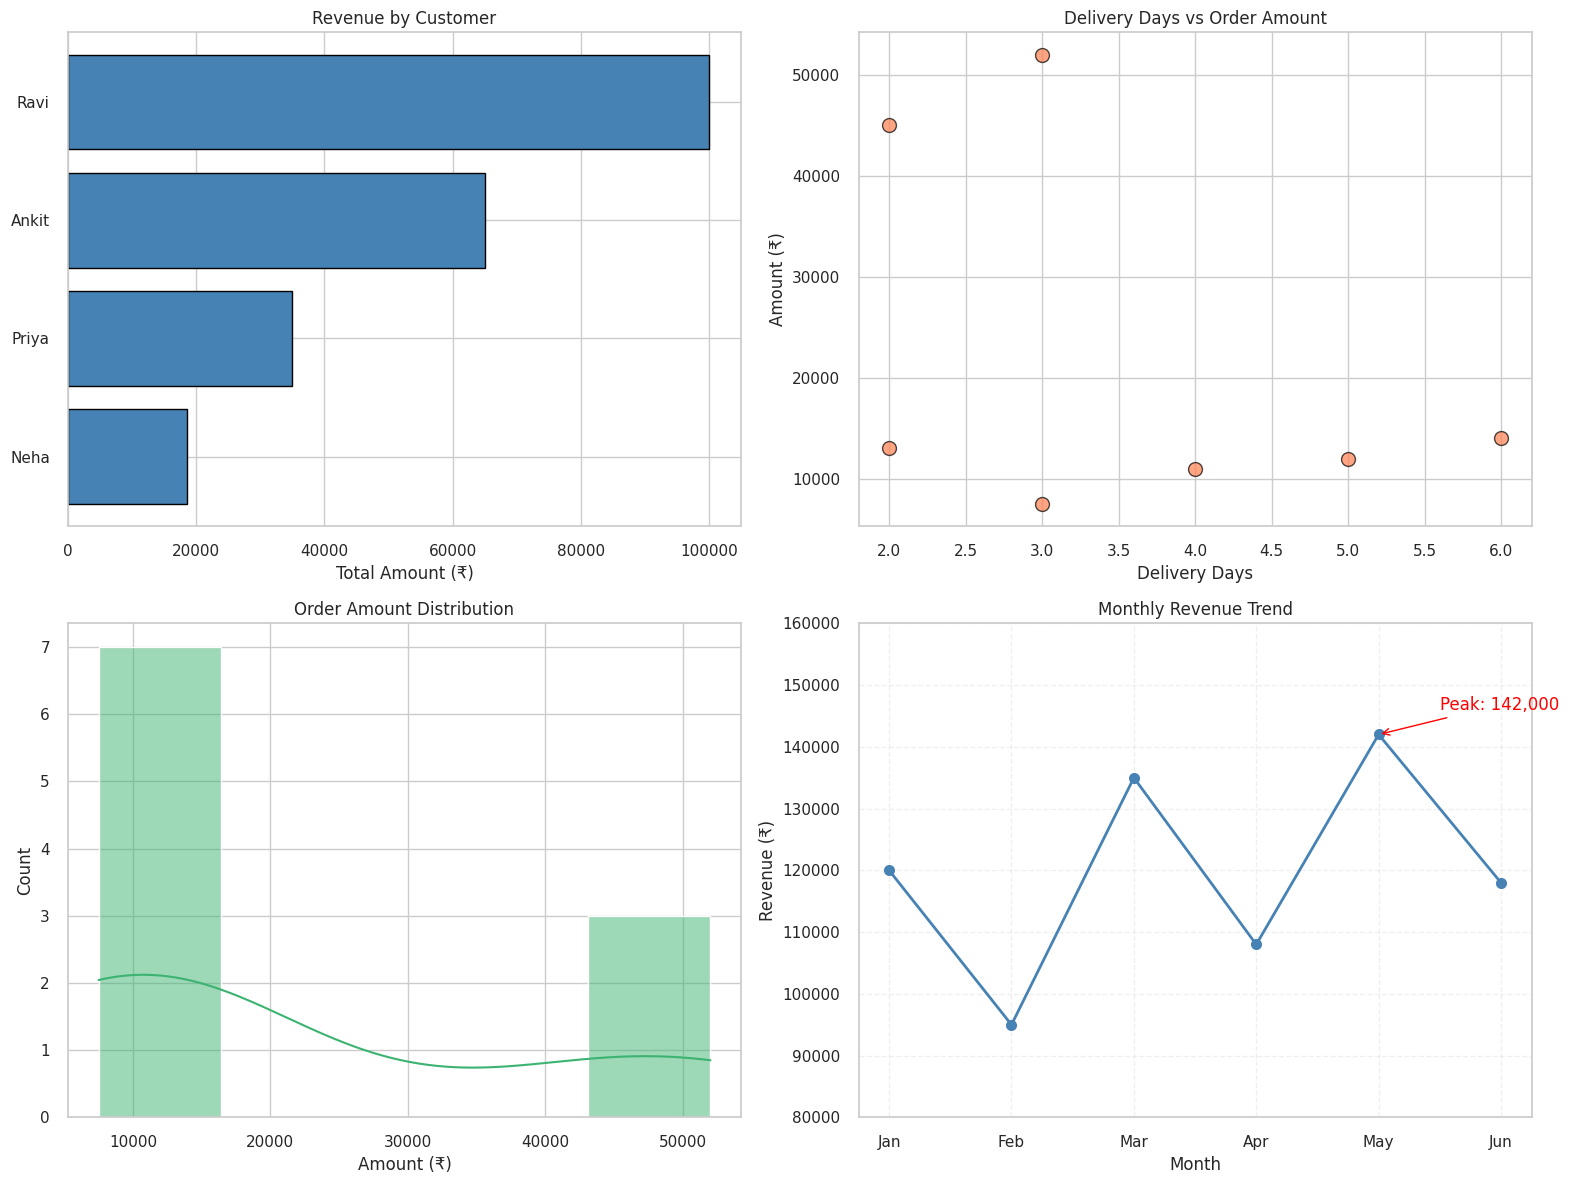

In [32]:
fig, axes=plt.subplots(2,2,figsize=(16,12))

# Top-left: horizontal bar — revenue by customer
customer_rev = df.groupby('customer')['amount'].sum().sort_values()
axes[0,0].barh(customer_rev.index, customer_rev.values,
               color='steelblue', edgecolor='black')
axes[0,0].set_title('Revenue by Customer')
axes[0,0].set_xlabel('Total Amount (₹)')

# Top-right: scatter — delivery days vs amount
delivered = df[df['status']=='delivered']
axes[0,1].scatter(delivered['delivery_days'], delivered['amount'],
                  color='coral', s=100, edgecolors='black', alpha=0.7)
axes[0,1].set_title('Delivery Days vs Order Amount')
axes[0,1].set_xlabel('Delivery Days')
axes[0,1].set_ylabel('Amount (₹)')

# Bottom-left: Seaborn histplot with KDE
sns.histplot(data=df, x='amount', kde=True,
             color='mediumseagreen', ax=axes[1,0])
axes[1,0].set_title('Order Amount Distribution')
axes[1,0].set_xlabel('Amount (₹)')

# Bottom-right: line chart — monthly revenue
months = ['Jan','Feb','Mar','Apr','May','Jun']
revenue = [120000, 95000, 135000, 108000, 142000, 118000]
axes[1,1].plot(months, revenue, marker='o', color='steelblue',
               linewidth=2, markersize=8)
max_val=max(revenue)
max_idx=revenue.index(max_val)
axes[1,1].annotate(
    f'Peak: {max_val:,}',
    xy=(max_idx,max_val),
    xytext=(max_idx+0.5,max_val+4000),
    arrowprops=dict(arrowstyle='->',color='red'),
    color='red'
)
axes[1,1].set_title('Monthly Revenue Trend')
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Revenue (₹)')
axes[1,1].set_ylim(80000, 160000)
axes[1,1].grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('ecommerce_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()